# PostgreSQL ArrayJSON Bigcache Zipfian Heavy Pure Internal Metrics Report

This notebook analyzes the internal PostgreSQL metrics captured directly inside the YCSB CSV files for the `postgresql_arrayjson_vacuum_notfull_bigcache_*_zipfian_heavy_pure` runs.

**Inputs analyzed**

- `JSON_BLUE/postgresql_arrayjson_vacuum_notfull_bigcache_run4_zipfian_heavy_pure.csv`
- `JSON_BLUE/postgresql_arrayjson_vacuum_notfull_bigcache_run5_zipfian_heavy_pure.csv`
- `JSON_BLUE/postgresql_arrayjson_vacuum_notfull_bigcache_run6_zipfian_heavy_pure.csv`

**Core idea**

The PostgreSQL counters in the CSVs are cumulative snapshots, so this notebook analyzes same-phase epoch deltas normalized by `Operations`, for example `diff(wal_bytes) / Operations`.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.style.use("seaborn-v0_8-whitegrid")

ROOT = Path.cwd()
JSON_BLUE_DIR = ROOT / "JSON_BLUE"
ANALYSIS_DIR = ROOT

RUNS = [4, 5, 6]
PHASES = ["run", "clean-run", "avg-run", "extend", "reference"]

phase_drift = pd.read_csv(ANALYSIS_DIR / "postgresql_arrayjson_bigcache_zipfian_internal_phase_drift.csv")
driver_summary = pd.read_csv(ANALYSIS_DIR / "postgresql_arrayjson_bigcache_zipfian_internal_driver_summary.csv")
run_read = pd.read_csv(ANALYSIS_DIR / "postgresql_arrayjson_bigcache_zipfian_internal_run_read_amplification.csv")
extend_storage = pd.read_csv(ANALYSIS_DIR / "postgresql_arrayjson_bigcache_zipfian_internal_extend_storage.csv")

phase_drift.head()

,run,phase,AverageLatency(us)_first10,AverageLatency(us)_last10,AverageLatency(us)_change_pct,Throughput(ops/sec)_first10,Throughput(ops/sec)_last10,Throughput(ops/sec)_change_pct,wal_bytes_per_op_first10,wal_bytes_per_op_last10,wal_bytes_per_op_change_pct,wal_records_per_op_first10,wal_records_per_op_last10,wal_records_per_op_change_pct,buffers_alloc_per_op_first10,buffers_alloc_per_op_last10,buffers_alloc_per_op_change_pct,buffers_clean_per_op_first10,buffers_clean_per_op_last10,buffers_clean_per_op_change_pct,blks_read_per_op_first10,blks_read_per_op_last10,blks_read_per_op_change_pct,blks_hit_per_op_first10,blks_hit_per_op_last10,blks_hit_per_op_change_pct,cache_hit_ratio_first10,cache_hit_ratio_last10,cache_hit_ratio_change_pct,checkpoint_write_time_per_op_first10,checkpoint_write_time_per_op_last10,checkpoint_write_time_per_op_change_pct
0,4,avg-run,72.408267,515.376588,611.764843,13493.418221,1920.728903,-85.765439,24622.652858,446619.423855,1713.855828,39.404921,544.004141,1280.548738,0.420876,41.832403,9839.375772,0.0,1.110147,NaN,-0.000153,0.0,-100.0,7.007311,0.612092,-91.264952,0.999893,0.999997,0.010351,1.333671,16.716501,1153.420042
1,5,avg-run,66.756185,466.878969,599.379344,14779.763637,2123.063281,-85.635337,24657.145344,444987.044891,1704.698146,39.264644,541.494306,1279.088780,0.422339,41.667640,9765.925468,0.0,1.004337,NaN,-0.000219,0.0,-100.0,7.008642,0.605485,-91.360880,0.999889,0.999997,0.010760,1.319083,16.112495,1121.491819
2,6,avg-run,76.207386,593.637611,678.976477,13115.225306,1665.512314,-87.300925,24567.686877,446233.790168,1716.344340,39.258753,544.466523,1286.866563,0.418637,41.388981,9786.611541,0.0,1.306740,NaN,-0.000138,0.0,-100.0,6.997170,0.698893,-90.011776,0.999894,0.999997,0.010284,1.344247,17.564534,1206.645159
3,4,clean-run,75.158184,477.609636,535.472560,13069.314460,2074.073317,-84.130206,24510.041112,446500.838892,1721.705793,39.230526,543.719511,1285.960303,0.407647,41.807124,10155.725710,0.0,1.110147,NaN,-0.000153,0.0,-100.0,2.909828,0.168319,-94.215500,0.999712,0.999993,0.028036,1.333671,16.707292,1152.729542
4,5,clean-run,66.957890,439.924488,557.016653,14833.904876,2251.346706,-84.822967,24544.002487,444869.867269,1712.540019,39.086212,541.228340,1284.703990,0.409110,41.642363,10078.769280,0.0,1.004337,NaN,-0.000219,0.0,-100.0,2.882992,0.199782,-93.070325,0.999705,0.999993,0.028795,1.319083,16.101122,1120.629629


## Executive Summary

Across runs `4`-`6`, the internal metrics strongly support a cumulative storage-amplification explanation.

- `run` latency rises from about **87.8 us** to **703.0 us**, while throughput falls from about **11,932** to **1,446 ops/sec**.
- `extend` is the clearest source phase: latency rises from about **1,659.9 us** to **10,429.7 us**, while throughput falls from about **614.7** to **96.0 ops/sec**.
- During `extend`, logical updates stay close to one update/op, but internal tuple inserts rise from about **8.3/op** to **136/op** and WAL bytes/op rises from roughly **24k** to **446k**.
- Later `run` phases show read amplification: tuples fetched/op increase from about **27.6** to **340+**, and block reads/op rise from near **0** to about **118-120**.

The strongest internal drivers are `wal_bytes_per_op`, `wal_records_per_op`, `buffers_alloc_per_op`, `tup_fetched_per_op`, `tup_returned_per_op`, `blks_read_per_op`, and `internal_inserts_per_logical_update`.

## Phase Drift

The table below aggregates first-10-epoch and last-10-epoch averages across runs. This gives a compact view of how each repeated phase changes over time.

In [3]:
metric_cols = [
    "AverageLatency(us)",
    "Throughput(ops/sec)",
    "wal_bytes_per_op",
    "wal_records_per_op",
    "buffers_alloc_per_op",
    "blks_read_per_op",
    "blks_hit_per_op",
    "cache_hit_ratio",
]

phase_agg_rows = []
for phase, group in phase_drift.groupby("phase", sort=False):
    row = {"phase": phase, "runs": group["run"].nunique()}
    for metric in metric_cols:
        row[f"{metric}_first10_mean"] = group[f"{metric}_first10"].mean()
        row[f"{metric}_last10_mean"] = group[f"{metric}_last10"].mean()
        row[f"{metric}_change_pct_mean"] = group[f"{metric}_change_pct"].mean()
    phase_agg_rows.append(row)

phase_agg = pd.DataFrame(phase_agg_rows)
phase_agg["phase"] = pd.Categorical(phase_agg["phase"], PHASES, ordered=True)
phase_agg = phase_agg.sort_values("phase")

phase_summary = phase_agg[[
    "phase",
    "runs",
    "AverageLatency(us)_first10_mean",
    "AverageLatency(us)_last10_mean",
    "AverageLatency(us)_change_pct_mean",
    "Throughput(ops/sec)_first10_mean",
    "Throughput(ops/sec)_last10_mean",
    "Throughput(ops/sec)_change_pct_mean",
]].copy()

phase_summary.round(2)

,phase,runs,AverageLatency(us)_first10_mean,AverageLatency(us)_last10_mean,AverageLatency(us)_change_pct_mean,Throughput(ops/sec)_first10_mean,Throughput(ops/sec)_last10_mean,Throughput(ops/sec)_change_pct_mean
4,run,3,87.81,702.96,709.61,11932.00,1445.99,-87.84
1,clean-run,3,75.15,503.88,568.50,13401.83,1996.03,-85.15
0,avg-run,3,71.79,525.30,630.04,13796.14,1903.10,-86.23
2,extend,3,1659.87,10429.74,528.29,614.74,96.04,-84.38
3,reference,3,37.38,43.49,16.24,24068.56,21077.58,-12.50


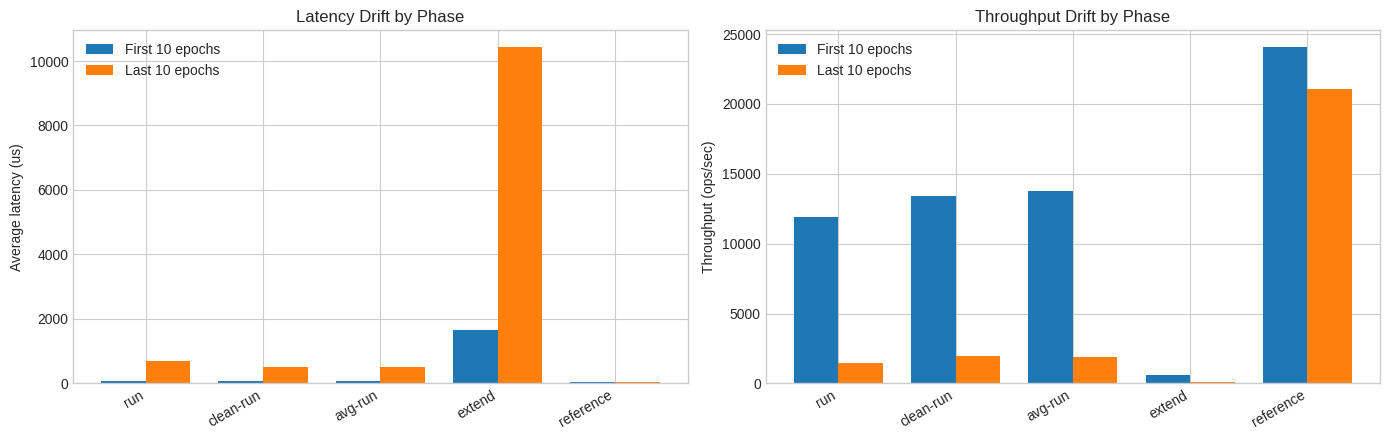

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

x = np.arange(len(phase_agg))
width = 0.38

axes[0].bar(x - width / 2, phase_agg["AverageLatency(us)_first10_mean"], width, label="First 10 epochs")
axes[0].bar(x + width / 2, phase_agg["AverageLatency(us)_last10_mean"], width, label="Last 10 epochs")
axes[0].set_xticks(x)
axes[0].set_xticklabels(phase_agg["phase"], rotation=30, ha="right")
axes[0].set_ylabel("Average latency (us)")
axes[0].set_title("Latency Drift by Phase")
axes[0].legend()

axes[1].bar(x - width / 2, phase_agg["Throughput(ops/sec)_first10_mean"], width, label="First 10 epochs")
axes[1].bar(x + width / 2, phase_agg["Throughput(ops/sec)_last10_mean"], width, label="Last 10 epochs")
axes[1].set_xticks(x)
axes[1].set_xticklabels(phase_agg["phase"], rotation=30, ha="right")
axes[1].set_ylabel("Throughput (ops/sec)")
axes[1].set_title("Throughput Drift by Phase")
axes[1].legend()

fig.tight_layout()

## Top Internal Drivers

Spearman correlation is used because the degradation is mostly monotonic over epochs. Values near `1.0` mean the metric rises as latency rises; values near `-1.0` mean the metric rises as throughput falls.

In [5]:
top_driver_rows = []
for phase in PHASES:
    sub = driver_summary[driver_summary["phase"] == phase].copy()
    top = (
        sub.groupby(["phase", "driver", "driver_label"], as_index=False)[["latency_spearman_rho", "throughput_spearman_rho"]]
        .mean()
        .assign(abs_latency_rho=lambda df: df["latency_spearman_rho"].abs())
        .sort_values("abs_latency_rho", ascending=False)
        .head(5)
    )
    top_driver_rows.append(top)

top_drivers = pd.concat(top_driver_rows, ignore_index=True)
top_drivers[["phase", "driver_label", "latency_spearman_rho", "throughput_spearman_rho"]].round(3)

,phase,driver_label,latency_spearman_rho,throughput_spearman_rho
0,run,Tuples returned/op,0.991,-0.991
1,run,Tuples fetched/op,0.991,-0.991
2,run,WAL bytes/op,0.991,-0.991
3,run,WAL records/op,0.991,-0.991
4,run,Internal tuple inserts/op,0.991,-0.991
5,clean-run,WAL bytes/op,0.998,-0.998
6,clean-run,WAL records/op,0.998,-0.998
7,clean-run,Cache-hit ratio,0.997,-0.997
8,clean-run,Buffer allocs/op,0.997,-0.997
9,clean-run,Checkpoint write time/op,0.997,-0.997


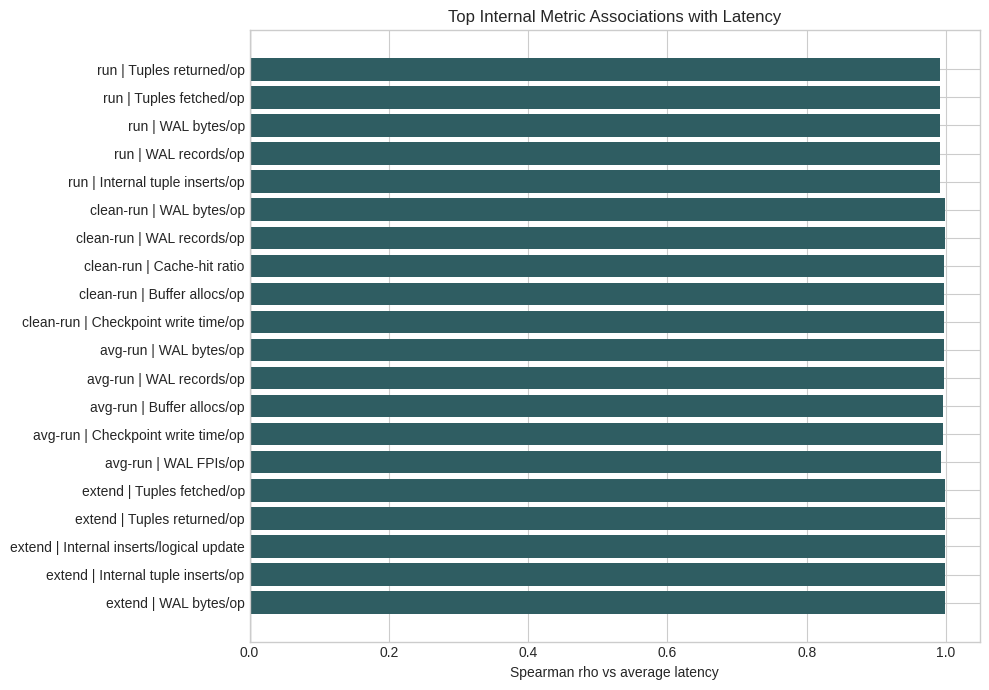

In [6]:
plot_df = top_drivers[top_drivers["phase"].isin(["run", "clean-run", "avg-run", "extend"])]
fig, ax = plt.subplots(figsize=(10, 7))

labels = plot_df["phase"] + " | " + plot_df["driver_label"]
y = np.arange(len(plot_df))
ax.barh(y, plot_df["latency_spearman_rho"], color="#2f5d62")
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Spearman rho vs average latency")
ax.set_title("Top Internal Metric Associations with Latency")
fig.tight_layout()

## Extend Storage Amplification

The `extend` phase is the most important source phase. Logical updates remain close to one update per operation, but PostgreSQL does much more internal work per logical operation late in the run.

In [7]:
extend_view = extend_storage[[
    "run",
    "tup_updated_per_op_first10",
    "tup_updated_per_op_last10",
    "tup_inserted_per_op_first10",
    "tup_inserted_per_op_last10",
    "internal_inserts_per_logical_update_first10",
    "internal_inserts_per_logical_update_last10",
    "wal_bytes_per_op_first10",
    "wal_bytes_per_op_last10",
]].copy()

extend_view.round(3)

,run,tup_updated_per_op_first10,tup_updated_per_op_last10,tup_inserted_per_op_first10,tup_inserted_per_op_last10,internal_inserts_per_logical_update_first10,internal_inserts_per_logical_update_last10,wal_bytes_per_op_first10,wal_bytes_per_op_last10
0,4,1.0,1.002,8.361,136.222,8.357,135.938,24247.505,446362.463
1,5,1.0,1.002,8.326,135.654,8.323,135.377,24287.430,444591.209
2,6,1.0,1.002,8.319,136.169,8.315,135.876,24188.750,445916.576


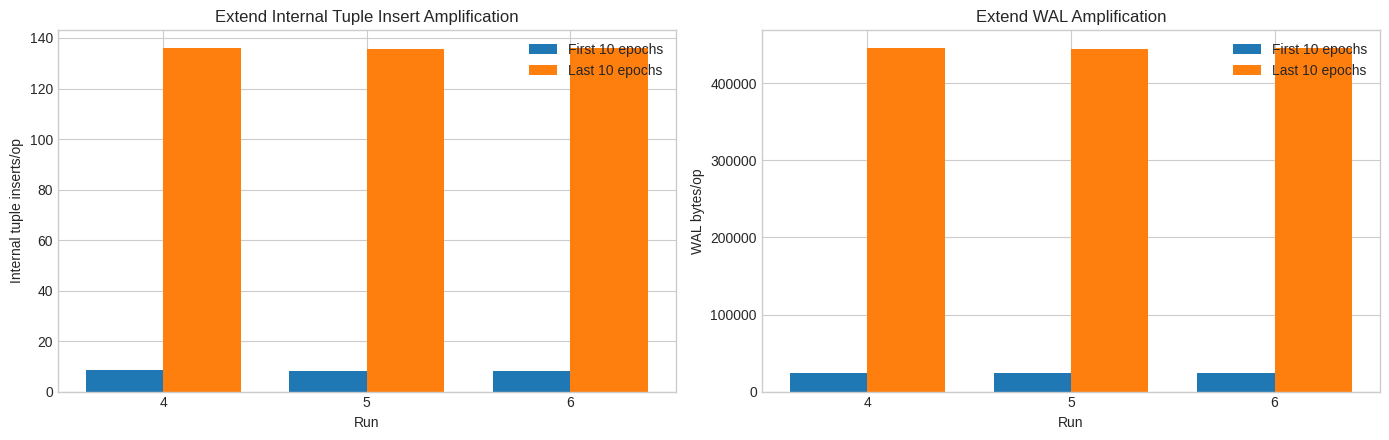

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

x = np.arange(len(extend_storage))
width = 0.38
run_labels = extend_storage["run"].astype(str)

axes[0].bar(x - width / 2, extend_storage["tup_inserted_per_op_first10"], width, label="First 10 epochs")
axes[0].bar(x + width / 2, extend_storage["tup_inserted_per_op_last10"], width, label="Last 10 epochs")
axes[0].set_xticks(x)
axes[0].set_xticklabels(run_labels)
axes[0].set_xlabel("Run")
axes[0].set_ylabel("Internal tuple inserts/op")
axes[0].set_title("Extend Internal Tuple Insert Amplification")
axes[0].legend()

axes[1].bar(x - width / 2, extend_storage["wal_bytes_per_op_first10"], width, label="First 10 epochs")
axes[1].bar(x + width / 2, extend_storage["wal_bytes_per_op_last10"], width, label="Last 10 epochs")
axes[1].set_xticks(x)
axes[1].set_xticklabels(run_labels)
axes[1].set_xlabel("Run")
axes[1].set_ylabel("WAL bytes/op")
axes[1].set_title("Extend WAL Amplification")
axes[1].legend()

fig.tight_layout()

## Run-Phase Read Amplification

After the extend-driven growth, read phases become progressively more expensive. The `run` phase shows rising tuple and block work per logical read.

In [9]:
run_read_view = run_read[[
    "run",
    "tup_returned_per_op_first10",
    "tup_returned_per_op_last10",
    "tup_fetched_per_op_first10",
    "tup_fetched_per_op_last10",
    "blks_read_per_op_first10",
    "blks_read_per_op_last10",
    "blks_hit_per_op_first10",
    "blks_hit_per_op_last10",
    "cache_hit_ratio_first10",
    "cache_hit_ratio_last10",
]].copy()

run_read_view.round(3)

,run,tup_returned_per_op_first10,tup_returned_per_op_last10,tup_fetched_per_op_first10,tup_fetched_per_op_last10,blks_read_per_op_first10,blks_read_per_op_last10,blks_hit_per_op_first10,blks_hit_per_op_last10,cache_hit_ratio_first10,cache_hit_ratio_last10
0,4,28.411,341.974,27.643,341.057,0.0,120.429,94.822,727.768,1.0,0.889
1,5,28.323,339.862,27.558,338.964,0.0,117.737,94.569,727.589,1.0,0.893
2,6,28.253,342.105,27.489,341.177,0.0,118.019,94.394,735.974,1.0,0.889


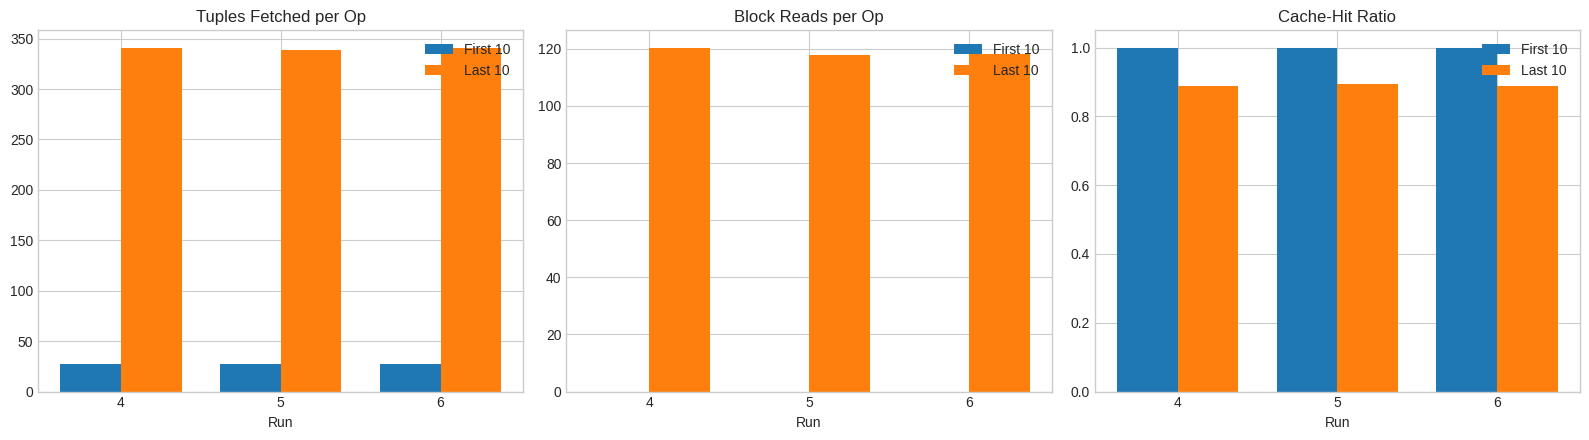

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

x = np.arange(len(run_read))
width = 0.38
run_labels = run_read["run"].astype(str)

axes[0].bar(x - width / 2, run_read["tup_fetched_per_op_first10"], width, label="First 10")
axes[0].bar(x + width / 2, run_read["tup_fetched_per_op_last10"], width, label="Last 10")
axes[0].set_xticks(x)
axes[0].set_xticklabels(run_labels)
axes[0].set_title("Tuples Fetched per Op")
axes[0].set_xlabel("Run")
axes[0].legend()

axes[1].bar(x - width / 2, run_read["blks_read_per_op_first10"], width, label="First 10")
axes[1].bar(x + width / 2, run_read["blks_read_per_op_last10"], width, label="Last 10")
axes[1].set_xticks(x)
axes[1].set_xticklabels(run_labels)
axes[1].set_title("Block Reads per Op")
axes[1].set_xlabel("Run")
axes[1].legend()

axes[2].bar(x - width / 2, run_read["cache_hit_ratio_first10"], width, label="First 10")
axes[2].bar(x + width / 2, run_read["cache_hit_ratio_last10"], width, label="Last 10")
axes[2].set_xticks(x)
axes[2].set_xticklabels(run_labels)
axes[2].set_ylim(0, 1.05)
axes[2].set_title("Cache-Hit Ratio")
axes[2].set_xlabel("Run")
axes[2].legend()

fig.tight_layout()

## Optional: Recompute Derived Metrics from Raw CSVs

The report above loads precomputed analysis tables. The cell below shows the derivation pattern used to create those tables: sort within phase, difference cumulative PostgreSQL counters, normalize by `Operations`, and correlate derived per-op metrics with latency and throughput.

In [11]:
COUNTERS = [
    "blks_read", "blks_hit", "tup_returned", "tup_fetched", "tup_inserted", "tup_updated",
    "buffers_checkpoint", "buffers_clean", "buffers_backend", "buffers_alloc",
    "checkpoint_write_time", "checkpoint_sync_time", "wal_bytes", "wal_records", "wal_fpi", "wal_buffers_full",
]

def load_raw_with_derived_metrics(run: int) -> pd.DataFrame:
    path = JSON_BLUE_DIR / f"postgresql_arrayjson_vacuum_notfull_bigcache_run{run}_zipfian_heavy_pure.csv"
    df = pd.read_csv(path)
    df = df[df["Phase"].isin(PHASES)].copy()
    df["run"] = run
    df["Epoch"] = pd.to_numeric(df["Epoch"], errors="coerce")
    df["Operations"] = pd.to_numeric(df["Operations"], errors="coerce")
    for col in COUNTERS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    derived = []
    for phase, phase_df in df.groupby("Phase"):
        phase_df = phase_df.sort_values("Epoch").copy()
        for col in COUNTERS:
            phase_df[f"{col}_per_op"] = phase_df[col].diff() / phase_df["Operations"]
        denom = (phase_df["blks_hit"] + phase_df["blks_read"]).replace(0, np.nan)
        phase_df["cache_hit_ratio"] = phase_df["blks_hit"] / denom
        phase_df["internal_inserts_per_logical_update"] = (
            phase_df["tup_inserted"].diff() / phase_df["tup_updated"].diff().replace(0, np.nan)
        )
        derived.append(phase_df)
    return pd.concat(derived, ignore_index=True)

raw_derived = pd.concat([load_raw_with_derived_metrics(run) for run in RUNS], ignore_index=True)
raw_derived[["run", "Phase", "Epoch", "AverageLatency(us)", "wal_bytes_per_op", "tup_fetched_per_op", "internal_inserts_per_logical_update"]].head(12)

FileNotFoundError: [Errno 2] No such file or directory: '/home/nhan/Desktop/Projects/YCSB-IVS-DATA/analysis/JSON_BLUE/postgresql_arrayjson_vacuum_notfull_bigcache_run4_zipfian_heavy_pure.csv'

## Bottom Line

The internal metrics captured inside the CSVs provide a stronger causal view than the external watcher metrics. The main driver is cumulative storage and write amplification during `extend`, visible as rapidly growing internal tuple inserts and WAL per operation. That growth then manifests as heavier read amplification in `run`, `clean-run`, and `avg-run`.